In [9]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import smarts_cerebellum.globals as gl

lme = pd.read_csv(os.path.join(gl.baseDir, 'lme', 'patients_MNISymC_FaMap_CST_lme.tsv'), sep = '\t')
lme['Week'] = lme['Week'].astype(int)
lme = lme.sort_values('Week')

obs = pd.read_csv(os.path.join(gl.baseDir, 'MNISymC_FaMap', 'summary_MNISymC_CST_FaMap.tsv'), sep = '\t')
#mcp = pd.read_csv(os.path.join(gl.baseDir, 'MNISymC_FaMap', 'summary_MNISymC_MCP_FaMap.tsv'), sep = '\t')

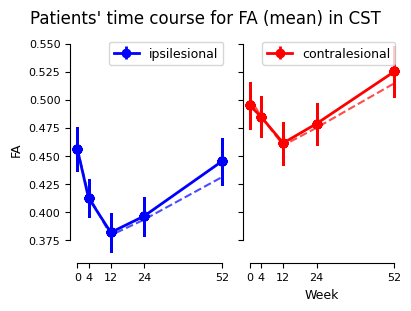

In [13]:
fig, axs = plt.subplots(1,2, figsize=(4,3), sharey = True, constrained_layout=True)

lme_ipsi = lme[(lme.regionname == 'right_CST')].sort_values('Week')
lme_contra = lme[(lme.regionname == 'left_CST')].sort_values('Week')

obs_ipsi = obs[obs.regionname == 'CSTR'].groupby('Week')['mean'].mean().reset_index()
obs_contra = obs[obs.regionname == 'CSTL'].groupby('Week')['mean'].mean().reset_index()

axs[0].errorbar(x = lme_ipsi['Week'], y = lme_ipsi['beta'], yerr = lme_ipsi['se'], fmt = '-o', linewidth = 2, color = 'blue', label = 'ipsilesional')
axs[1].errorbar(x = lme_contra['Week'], y = lme_contra['beta'], yerr = lme_contra['se'], fmt = '-o', linewidth = 2, color = 'red', label = 'contralesional')

axs[0].plot(obs_ipsi['Week'], obs_ipsi['mean'], alpha = .7, linestyle = '--', color = 'blue')
axs[1].plot(obs_contra['Week'], obs_contra['mean'], alpha = .7, linestyle = '--', color = 'red')

for ax in axs:
    ax.legend()
    ax.set_xticks(gl.weeks)
    axs[0].set_ylabel("FA")
    axs[1].set_xlabel("Week")

plt.suptitle(f"Patients' time course for FA (mean) in CST")
sns.despine(trim = True)
plt.show()

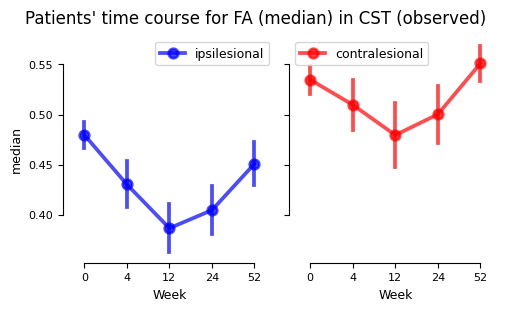

In [14]:
fig, axs = plt.subplots(1,2, figsize = (5,3), sharey = True, sharex = True, constrained_layout = True)
sns.pointplot(x = 'Week', y = 'median', data = obs[obs.group == 'ipsilesional'], alpha = .7, label = f'ipsilesional', color = 'blue', ax = axs[0], errorbar = 'se')
sns.pointplot(x = 'Week', y = 'median', data = obs[obs.group == 'contralesional'], alpha = .7, label = f'contralesional', color = 'red', ax = axs[1], errorbar = 'se')

plt.suptitle("Patients' time course for FA (median) in CST (observed)")
plt.legend()
sns.despine(trim = True)
plt.show()

these changes (the upward trend from W12 to W52) was also obs in the DTI Jing provided (with Mori's atlas), but to a considerably lesser degree. I think these changes are not super robust, just atlas-dependent.

In [15]:
from scipy import stats

print(f'---t-test between ipsilesional and contralesional obs patients--- \n')

for week in obs.Week.unique():
    t_val, p_val = stats.ttest_rel(obs[(obs.Week == week) & (obs.regionname == f'CSTR')]['mean'], obs[(obs.Week == week) & (obs.regionname == f'CSTL')]['mean'])
    print(f'Week {week}: t-value = {t_val}, p-value = {p_val} \n')
    

---t-test between ipsilesional and contralesional obs patients--- 

Week 0: t-value = -3.9392762526932876, p-value = 0.002778131941949696 

Week 4: t-value = -7.052948273347755, p-value = 2.7307868716828188e-06 

Week 12: t-value = -5.898340722935204, p-value = 3.8791825338380154e-05 

Week 24: t-value = -7.243312292209156, p-value = 2.862737382900045e-06 

Week 52: t-value = -6.933276691277527, p-value = 0.00012042426284649332 

